# 4. Preparing your data for the estimator

Notebooks 01 to 03 handed the estimator clean arrays. Neural data arrives as
spike times, a tracked trajectory or trial labels on different clocks and with
stretches missing.

Notebook 02 separated what the data hands you from what you control. The data is
what it is. We covered the intuition behind it there. This notebook covers what
you do to the data before training starts.

**Part I** turns a recording into tensors.

**Part II** decides which tensors the estimator learns from and which it is
scored on.

**Part III** does both on two real hippocampal recordings.

## Imports

In [1]:
import pickle
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
import neural_mi as nmi
from collections import OrderedDict
from neural_mi.data.handler import create_dataset

from neural_mi.generators import SharedLatentGaussian

DATA = 'data'

## Cost knobs

In [2]:
# --- Cost knobs -----------------------------------------------------------
# Safe to reduce. These cost precision and leave the conclusions standing.

T             = 10_000               # samples for the synthetic split sweep
COVERAGE_GRID = [0.0, 0.5, 0.9]      # min_coverage_fraction values compared
N_EPOCHS      = 200

# Load-bearing.

N_SEEDS = 3
OVERLAP_STEPS = [1, 2, 5, 10]
SPLIT_MODES = ['blocked', 'random']
# Section 6 needs both split modes and more than one overlap. One mode gives a
# number with nothing to compare it to, and one overlap cannot separate the
# overlap from the split.

W = 10          # window size for the split sweep, in samples
SEED = 0

N_WORKERS = 4
# How many runs go at once. Set it to your core count: every repeat below is an
# independent job and the library dispatches them to a pool.

rng = np.random.default_rng(SEED)   # every synthetic example in Part I

# Quick pass: OVERLAP_STEPS = [1, 10] and N_SEEDS = 2. That still shows the
# inflation and its absence, and it cannot support the claim that blocked
# splitting is unaffected at every overlap.
# Heavy cell: section 7.

# Part I. From a recording to a tensor

## 1. The shape the estimator expects

Whatever you start with, the estimator is handed one shape,

$$(\,n_\text{samples},\; n_\text{channels},\; \text{width}\,)$$

for $X$, the same for $Y$, and the same again for $W$. The first axis is what
the estimator treats as an independent draw. The last axis is the contents of
one draw. Three processors build it for the three kinds of data.

You can also skip the processors by handing `run` a three-dimensional array with
no `processing=` argument for it to use as it stands. Cut your recording however
you like and pair it with whatever architecture suits it. The only contract is
that the estimator sees a chunk of $X$ and the matching chunk of $Y$.

## 2. Continuous, spike, and categorical data

The next three figures are drawn the same way. The raw recording sits on top
with the window boundaries marked and two neighbouring windows picked out in
red and green. What those two windows became sits underneath in the same two
colours.

### Continuous

This covers voltage, position, a behavioural variable, anything sampled on a clock.

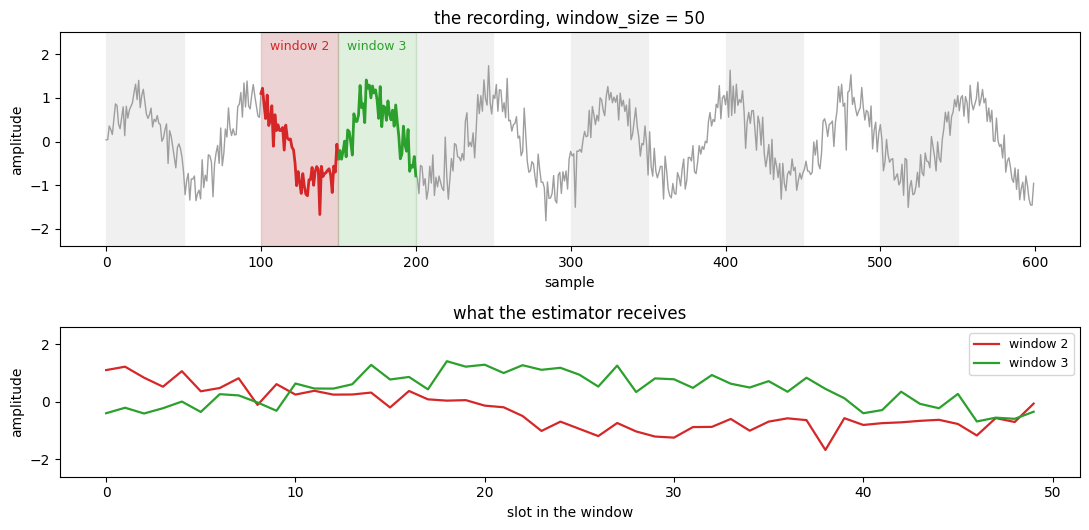

In [3]:
FS, DUR, W_CONT = 100, 6.0, 50           # 100 Hz, 6 s, windows of 50 samples
A, B = 2, 3                              # the two windows drawn in every figure
RED, GREEN = 'tab:red', 'tab:green'

t_cont = np.arange(0, DUR, 1 / FS)
trace = (np.sin(2 * np.pi * 1.3 * t_cont)
         + 0.3 * rng.standard_normal(len(t_cont)))[:, None]
d_cont = create_dataset(trace, processor_type_x='continuous',
                        processor_params_x={'window_size': W_CONT,
                                            'step_size': W_CONT})
tens_cont = np.asarray(d_cont.x_data)

fig, (top, bot) = plt.subplots(2, 1, figsize=(11, 5.4),
                               gridspec_kw={'height_ratios': [2, 1.4]})
top.plot(np.arange(len(trace)), trace[:, 0], color='0.62', lw=1)
for k in range(len(trace) // W_CONT):
    if k % 2 == 0:
        top.axvspan(k * W_CONT, (k + 1) * W_CONT, color='0.94', zorder=0)
for k, colour in ((A, RED), (B, GREEN)):
    top.axvspan(k * W_CONT, (k + 1) * W_CONT, color=colour, alpha=0.15, zorder=0)
    span = np.arange(k * W_CONT, (k + 1) * W_CONT + 1)
    top.plot(span, trace[span, 0], color=colour, lw=2)
    top.text((k + 0.5) * W_CONT, 2.1, f'window {k}', color=colour,
             ha='center', fontsize=9)
top.set_ylim(-2.4, 2.5)
top.set_xlabel('sample')
top.set_ylabel('amplitude')
top.set_title(f'the recording, window_size = {W_CONT}')

for k, colour in ((A, RED), (B, GREEN)):
    bot.plot(tens_cont[k, 0], color=colour, lw=1.6, label=f'window {k}')
bot.set_ylim(-2.6, 2.6)
bot.set_xlabel('slot in the window')
bot.set_ylabel('amplitude')
bot.set_title(f'what the estimator receives')
bot.legend(fontsize=9, loc='upper right')

fig.tight_layout()
plt.show()

### Spikes

Spike data is a list of timestamp arrays of different lengths with one array per
neuron.

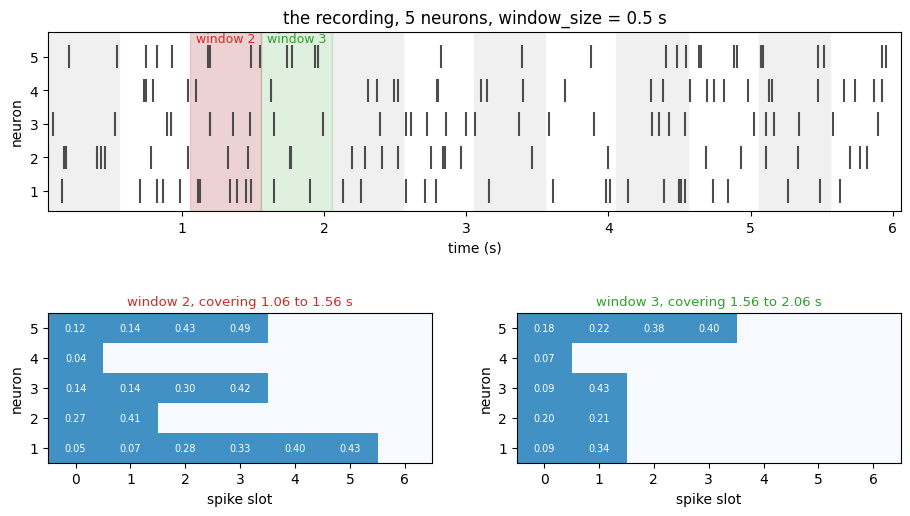

In [4]:
DUR_SP, N_NEUR, W_SPIKE = 6.0, 5, 0.5
spike_demo = [np.sort(rng.uniform(0, DUR_SP, size=rng.integers(18, 34)))
              for _ in range(N_NEUR)]
# step_size is left out, so windows touch without overlapping. Anything below 1
# would be read as a fraction of the window: section 5 covers that.
d_spike = create_dataset(spike_demo, processor_type_x='spike',
                         processor_params_x={'window_size': W_SPIKE})
tens_spike = np.asarray(d_spike.x_data)
# The window grid starts at the first spike, not at zero, so read the actual
# window starts instead of assuming them.
edges = d_spike.window_manager.window_times
neurons = np.arange(1, N_NEUR + 1)

fig = plt.figure(figsize=(11, 5.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.8, 1.5], hspace=0.62, wspace=0.22)

top = fig.add_subplot(gs[0, :])
top.eventplot(spike_demo, colors='0.3', lineoffsets=neurons, linelengths=0.7)
for k, left in enumerate(edges):
    if k % 2 == 0:
        top.axvspan(left, left + W_SPIKE, color='0.94', zorder=0)
for k, colour in ((A, RED), (B, GREEN)):
    top.axvspan(edges[k], edges[k] + W_SPIKE, color=colour, alpha=0.15, zorder=0)
    top.text(edges[k] + W_SPIKE / 2, N_NEUR + 0.43, f'window {k}', color=colour,
             ha='center', fontsize=9)
top.set_xlim(edges[0], edges[-1] + W_SPIKE)
top.set_ylim(0.4, N_NEUR + 0.75)
top.set_yticks(neurons)
top.set_xlabel('time (s)')
top.set_ylabel('neuron')
top.set_title(f'the recording, {N_NEUR} neurons, window_size = {W_SPIKE} s')

for j, (k, colour) in enumerate(((A, RED), (B, GREEN))):
    ax = fig.add_subplot(gs[1, j])
    filled = tens_spike[k] != 0.0
    ax.imshow(filled, aspect='auto', cmap='Blues', vmin=0, vmax=1.6,
              origin='lower', interpolation='nearest',
              extent=[-0.5, tens_spike.shape[2] - 0.5, 0.5, N_NEUR + 0.5])
    for r in range(N_NEUR):
        for c in range(tens_spike.shape[2]):
            if filled[r, c]:
                ax.text(c, r + 1, f'{tens_spike[k, r, c]:.2f}', ha='center',
                        va='center', fontsize=7, color='w')
    ax.set_xticks(range(tens_spike.shape[2]))
    ax.set_yticks(neurons)
    ax.set_xlabel('spike slot')
    ax.set_ylabel('neuron')
    ax.set_title(f'window {k}, covering {edges[k]:.2f} to {edges[k] + W_SPIKE:.2f} s',
                 color=colour, fontsize=9.5)

plt.show()

The trailing axis holds one slot per spike carrying the spike's time in seconds
from the start of its window. Its length is set by the busiest window anywhere
in the recording, up to `max_spikes_per_window`. A quiet window is mostly
padding.

### Categorical

Categorical data is integer labels such as trial type, running direction, or a discretised
stimulus.

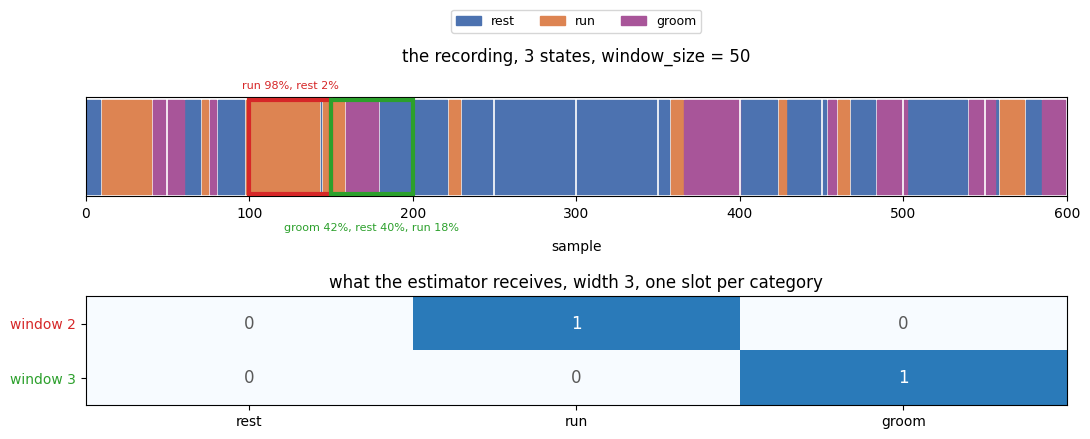

In [5]:
NT, W_CAT = 600, 50
STATES = ['rest', 'run', 'groom']
STATE_COLS = ['#4C72B0', '#DD8452', "#A85599"]

state = np.zeros(NT, dtype=int)
s = 0
for i in range(NT):
    if rng.random() < 0.06:
        s = int(rng.integers(0, 3))
    state[i] = s
d_cat = create_dataset(state, processor_type_x='categorical',
                       processor_params_x={'window_size': W_CAT,
                                           'step_size': W_CAT})
tens_cat = np.asarray(d_cat.x_data)

fig, (top, bot) = plt.subplots(2, 1, figsize=(11, 5.2),
                               gridspec_kw={'height_ratios': [1, 1.1]})
for j in range(3):
    top.fill_between(np.arange(NT), 0, 1, where=(state == j),
                     color=STATE_COLS[j], step='post')
for k in range(NT // W_CAT):
    top.axvline(k * W_CAT, color='w', lw=1.2)
for j, (k, colour) in enumerate(((A, RED), (B, GREEN))):
    top.add_patch(Rectangle((k * W_CAT, 0), W_CAT, 1, fill=False, ec=colour,
                            lw=3, zorder=5))
    inside = state[k * W_CAT:(k + 1) * W_CAT]
    share = ', '.join(f'{STATES[c]} {100 * np.mean(inside == c):.0f}%'
                      for c in np.argsort(-np.bincount(inside, minlength=3))
                      if np.any(inside == c))
    top.text((k + 0.5) * W_CAT, 1.12 if j == 0 else -0.40, share,
             color=colour, ha='center', fontsize=8)
top.set_xlim(0, NT)
top.set_ylim(-0.03, 1.03)
top.set_yticks([])
top.set_xlabel('sample', labelpad=14)
top.set_title(f'the recording, 3 states, window_size = {W_CAT}', pad=26)
top.legend(handles=[Patch(color=STATE_COLS[j], label=STATES[j]) for j in range(3)],
           ncol=3, fontsize=9, loc='upper center', bbox_to_anchor=(0.5, 1.95))

pair = np.stack([tens_cat[A, 0], tens_cat[B, 0]])
bot.imshow(pair, aspect='auto', cmap='Blues', vmin=0, vmax=1.4,
           interpolation='nearest')
for r in range(2):
    for c in range(3):
        bot.text(c, r, f'{pair[r, c]:.0f}', ha='center', va='center',
                 fontsize=12, color='w' if pair[r, c] else '0.35')
bot.set_xticks(range(3))
bot.set_xticklabels(STATES)
bot.set_yticks([0, 1])
bot.set_yticklabels([f'window {A}', f'window {B}'])
for label, colour in zip(bot.get_yticklabels(), (RED, GREEN)):
    label.set_color(colour)
bot.set_title(f'what the estimator receives, width {d_cat.x_window_width}, '
              'one slot per category')

fig.tight_layout()
plt.show()

In [6]:
for w in (2, 5, 10, 25):
    dc = create_dataset(trace, processor_type_x='continuous',
                        processor_params_x={'window_size': w, 'step_size': w})
    dk = create_dataset(state, processor_type_x='categorical',
                        processor_params_x={'window_size': w, 'step_size': w})
    print(f"window_size={w:>3}   continuous width {dc.x_window_width:>3}, "
          f"{len(dc):>4} windows   |   categorical width {dk.x_window_width:>3}, "
          f"{len(dk):>4} windows")

window_size=  2   continuous width   2,  300 windows   |   categorical width   3,  300 windows
window_size=  5   continuous width   5,  120 windows   |   categorical width   3,  120 windows
window_size= 10   continuous width  10,   60 windows   |   categorical width   3,   60 windows
window_size= 25   continuous width  25,   24 windows   |   categorical width   3,   24 windows


The trailing axis holds one slot per category and does not move when
`window_size` does. The default encoding takes a majority vote over the window
and one-hot encodes the winner. Window size still sets how many windows get
built. Every transition inside a window is gone by the time the estimator sees
it.

The processor parameter `encoding=` offers two alternatives to the majority
vote.

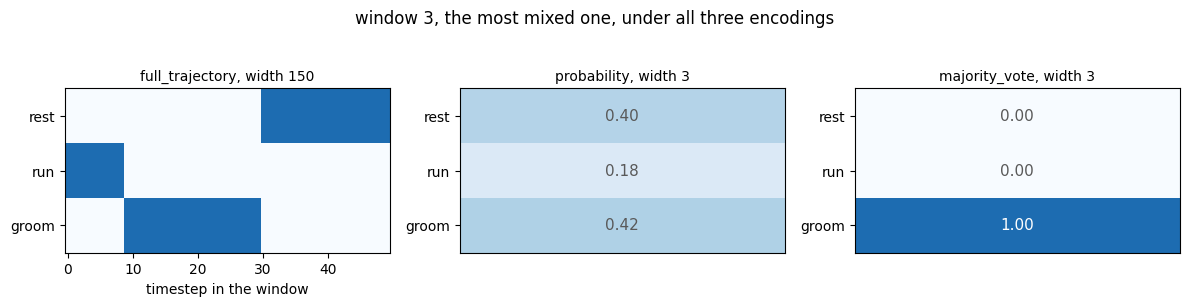

In [7]:
ENCODINGS = ['full_trajectory', 'probability', 'majority_vote']

# The comparison only says something on a window that holds a mixture,
# so pick the one whose winning state takes the smallest share.
shares = np.asarray(create_dataset(
    state[:, None], processor_type_x='categorical',
    processor_params_x={'window_size': W_CAT, 'step_size': W_CAT,
                        'encoding': 'probability'}).x_data)[:, 0]
MIX = int(np.argmin(shares.max(axis=1)))

fig, axes = plt.subplots(1, 3, figsize=(12, 2.9))
for ax, enc in zip(axes, ENCODINGS):
    d_enc = create_dataset(state[:, None], processor_type_x='categorical',
                           processor_params_x={'window_size': W_CAT,
                                               'step_size': W_CAT,
                                               'encoding': enc})
    row = np.asarray(d_enc.x_data)[MIX, 0]
    grid = row.reshape(-1, 3).T if enc == 'full_trajectory' else row[:, None]
    ax.imshow(grid, aspect='auto', cmap='Blues', vmin=0, vmax=1.3,
              interpolation='nearest')
    ax.set_yticks(range(3))
    ax.set_yticklabels(STATES)
    ax.set_title(f'{enc}, width {d_enc.x_window_width}', fontsize=10)
    if enc == 'full_trajectory':
        ax.set_xlabel('timestep in the window')
    else:
        ax.set_xticks([])
        for c in range(3):
            ax.text(0, c, f'{row[c]:.2f}', ha='center', va='center',
                    fontsize=11, color='w' if row[c] > 0.5 else '0.35')
fig.suptitle(f'window {MIX}, the most mixed one, under all three encodings',
             y=1.04)
fig.tight_layout()
plt.show()

`full_trajectory` keeps every timestep and pays for it in width. `probability`
keeps the mixture and drops the order. `majority_vote` keeps the winner alone.

The choice sets the width and what survives into the estimate.

## 3. What windowing assumes and discards

Cutting a recording into windows commits you to these assumptions.

**Nothing you care about changes inside a window.** The window then holds a single sample.
Your window length is bounded above by the timescale of the question you are
asking.

**Windows are exchangeable draws from one distribution.** The estimator sees a
bag of samples in no particular order. Drift across a session violates this
silently.

**The window is a sufficient summary.** Context outside it is unavailable. A
dependence that needs two seconds is not recoverable from half-second windows.

**The encoding keeps what matters.** Your choice specifies what you keep.

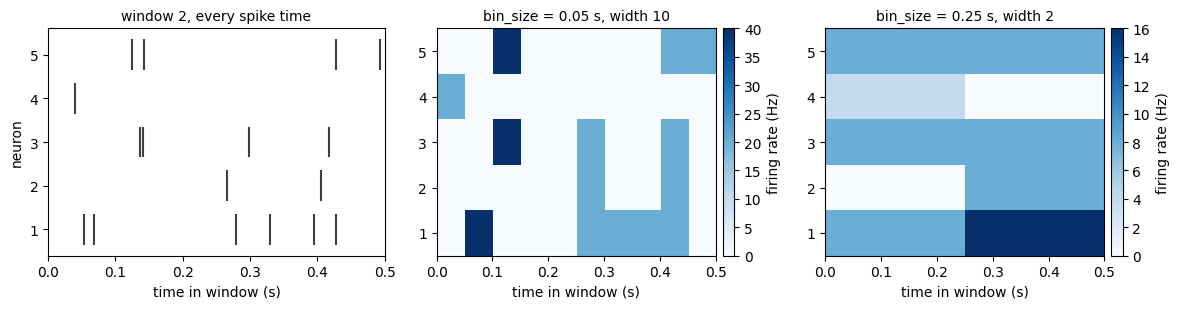

In [8]:
BINS = [0.05, 0.25]
win_idx = A
win_start = d_spike.window_manager.window_times[win_idx]
# The same window the tensor above holds, read off the same grid.
one_window = [s[(s >= win_start) & (s < win_start + W_SPIKE)] - win_start
              for s in spike_demo]

fig, axes = plt.subplots(1, 1 + len(BINS), figsize=(12, 3.2))
axes[0].eventplot(one_window, colors='0.25', lineoffsets=neurons, linelengths=0.7)
axes[0].set_xlim(0, W_SPIKE)
axes[0].set_ylim(0.4, N_NEUR + 0.6)
axes[0].set_yticks(neurons)
axes[0].set_xlabel('time in window (s)')
axes[0].set_ylabel('neuron')
axes[0].set_title(f'window {win_idx}, every spike time', fontsize=10)

for ax, bin_size in zip(axes[1:], BINS):
    binned = create_dataset(spike_demo, processor_type_x='spike',
                            processor_params_x={'window_size': W_SPIKE,
                                                'bin_size': bin_size})
    arr = np.asarray(binned.x_data)[win_idx]
    im = ax.imshow(arr, aspect='auto', cmap='Blues', interpolation='nearest',
                   origin='lower', extent=[0, W_SPIKE, 0.5, N_NEUR + 0.5])
    ax.set_yticks(neurons)
    ax.set_xlabel('time in window (s)')
    ax.set_title(f'bin_size = {bin_size} s, width {binned.x_window_width}',
                 fontsize=10)
    fig.colorbar(im, ax=ax, label='firing rate (Hz)', pad=0.02)

fig.tight_layout()
plt.show()

The three panels are the same window under three encodings. The left one keeps
every spike time. The other two bin the spikes into firing rates. Each step to
the right discards the structure below the new bin width.

Because processing can destroy information about $Y$ and can never create it,
every encoding choice sets a ceiling on what any estimator can find afterwards.

The question before windowing is which structure your question depends on and
whether your encoding keeps it. Binning at 50 ms is safe when you are asking
about firing rates. It leaves no way at all to find millisecond synchrony.

## 4. Aligning two streams on different clocks

Because spikes are timestamps and position is sampled at whatever the tracking
camera ran at, the two cover different spans on different grids.

Pass each stream's own time vector as `x_time` and `y_time`. Windows are then
defined in seconds on a shared timeline.

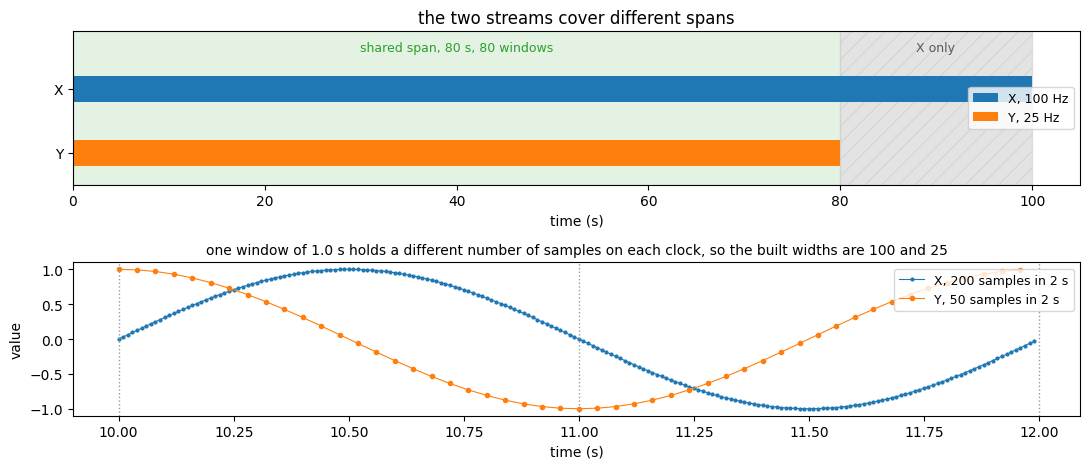

In [9]:
X_FS, X_DUR, Y_FS, Y_DUR, WIN_S = 100.0, 100.0, 25.0, 80.0, 1.0
xt = np.arange(0, X_DUR, 1 / X_FS)
yt = np.arange(0, Y_DUR, 1 / Y_FS)
xs = np.sin(2 * np.pi * 0.5 * xt)[:, None]
ys = np.cos(2 * np.pi * 0.5 * yt)[:, None]

d_pair = create_dataset(xs, ys, x_time=xt, y_time=yt,
                        processor_type_x='continuous',
                        processor_params_x={'window_size': WIN_S,
                                            'step_size': WIN_S},
                        processor_type_y='continuous',
                        processor_params_y={'window_size': WIN_S,
                                            'step_size': WIN_S})
shared = min(xt[-1], yt[-1])

fig, (span_ax, zoom_ax) = plt.subplots(2, 1, figsize=(11, 4.8))
span_ax.barh(1, xt[-1], height=0.4, color='tab:blue', label=f'X, {X_FS:.0f} Hz')
span_ax.barh(0, yt[-1], height=0.4, color='tab:orange', label=f'Y, {Y_FS:.0f} Hz')
span_ax.axvspan(0, shared, color='tab:green', alpha=0.13, zorder=0)
span_ax.axvspan(shared, xt[-1], color='0.8', alpha=0.55, hatch='//', zorder=0)
span_ax.text(shared / 2, 1.6, f'shared span, {shared:.0f} s, {len(d_pair)} windows',
             ha='center', fontsize=9, color='tab:green')
span_ax.text((shared + xt[-1]) / 2, 1.6, 'X only', ha='center', fontsize=9,
             color='0.35')
span_ax.set_yticks([0, 1])
span_ax.set_yticklabels(['Y', 'X'])
span_ax.set_ylim(-0.5, 1.9)
span_ax.set_xlabel('time (s)')
span_ax.set_title('the two streams cover different spans')
span_ax.legend(fontsize=9, loc='center right')

mx = (xt >= 10) & (xt < 12)
my = (yt >= 10) & (yt < 12)
zoom_ax.plot(xt[mx], xs[mx, 0], '.-', ms=4, lw=0.8, color='tab:blue',
             label=f'X, {mx.sum()} samples in 2 s')
zoom_ax.plot(yt[my], ys[my, 0], '.-', ms=6, lw=0.8, color='tab:orange',
             label=f'Y, {my.sum()} samples in 2 s')
for k in (10, 11, 12):
    zoom_ax.axvline(k, color='0.6', ls=':', lw=1)
zoom_ax.set_xlabel('time (s)')
zoom_ax.set_ylabel('value')
zoom_ax.set_title(f'one window of {WIN_S} s holds a different number of samples on '
                  f'each clock, so the built widths are {d_pair.x_window_width} '
                  f'and {d_pair.y_window_width}', fontsize=10)
zoom_ax.legend(fontsize=9, loc='upper right')

fig.tight_layout()
plt.show()

The window count follows the span the two streams share. The widths differ
because a second holds a different number of samples on each clock.

## 5. Window overlap and `step_size`

`step_size` sets how far the window advances between samples. Its meaning
depends on which side of 1 it falls.

| `step_size` | meaning |
|---|---|
| `None` (default) | one full window (windows touch) |
| $0 < s < 1$ | a fraction of `window_size` (`0.25` is 75% overlap) |
| $s \ge 1$ | an absolute step in the same units as `window_size` |

**Note:** `window_size=0.5, step_size=0.5` reads as a 0.25 s step and 50% overlap. The
library warns whenever `window_size` is below 1 and `step_size` falls in
$(0, 1)$, naming the step it applied.

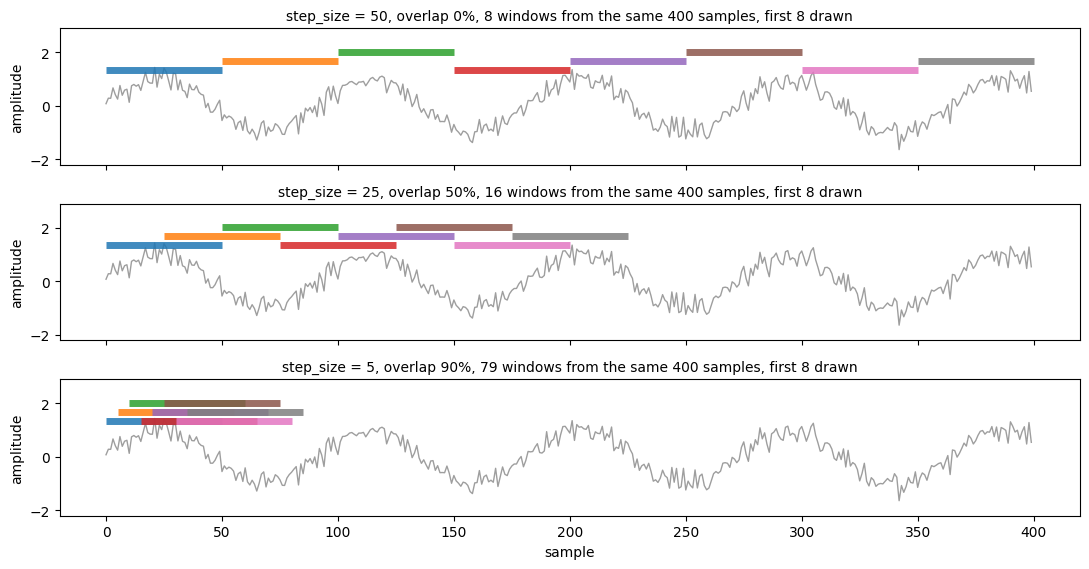

In [10]:
FS_OV, DUR_OV, W_OV = 100, 4.0, 50
t_ov = np.arange(0, DUR_OV, 1 / FS_OV)
sig_ov = (np.sin(2 * np.pi * 1.1 * t_ov)
          + 0.22 * rng.standard_normal(len(t_ov)))[:, None]

fig, axes = plt.subplots(3, 1, figsize=(11, 5.8), sharex=True)
for ax, step in zip(axes, (50, 25, 5)):
    ax.plot(np.arange(len(sig_ov)), sig_ov[:, 0], color='0.62', lw=1)
    d_ov = create_dataset(sig_ov, processor_type_x='continuous',
                          processor_params_x={'window_size': W_OV,
                                              'step_size': step})
    for k in range(8):
        ax.plot([k * step, k * step + W_OV], [1.35 + 0.34 * (k % 3)] * 2, lw=5,
                solid_capstyle='butt', color=plt.get_cmap('tab10')(k % 10),
                alpha=0.85)
    ax.set_ylim(-2.2, 2.9)
    ax.set_ylabel('amplitude')
    ax.set_title(f'step_size = {step}, overlap {100 * (1 - step / W_OV):.0f}%, '
                 f'{len(d_ov)} windows from the same {len(sig_ov)} samples, '
                 'first 8 drawn', fontsize=10)
axes[-1].set_xlabel('sample')

fig.tight_layout()
plt.show()

The first eight windows cover the whole recording at no overlap and about a fifth of
it at ninety percent. Ten times the windows come out of the same four hundred
samples. Ten times the windows is not ten times the evidence.

# Part II. Splitting into training and evaluation

## 6. Why overlapping windows break a random split

A neural estimator learns a critic on one part of your data and is scored on
another. Because every sample in notebooks 01 and 02 was an independent draw,
shuffling the rows and cutting gave two sets that shared nothing.

Windows cut from one recording are not independent draws. A shuffle can put one
of two windows that overlap in time in training and its near-duplicate in
evaluation. If the critic is scored on data it has already seen, the estimate
wrongly goes up.

`Split(mode='random')` shuffles the windows and cuts the shuffled order.
`Split(mode='blocked')`, the default, takes the evaluation set as a few
contiguous runs of windows and drops a buffer on each side of every run.

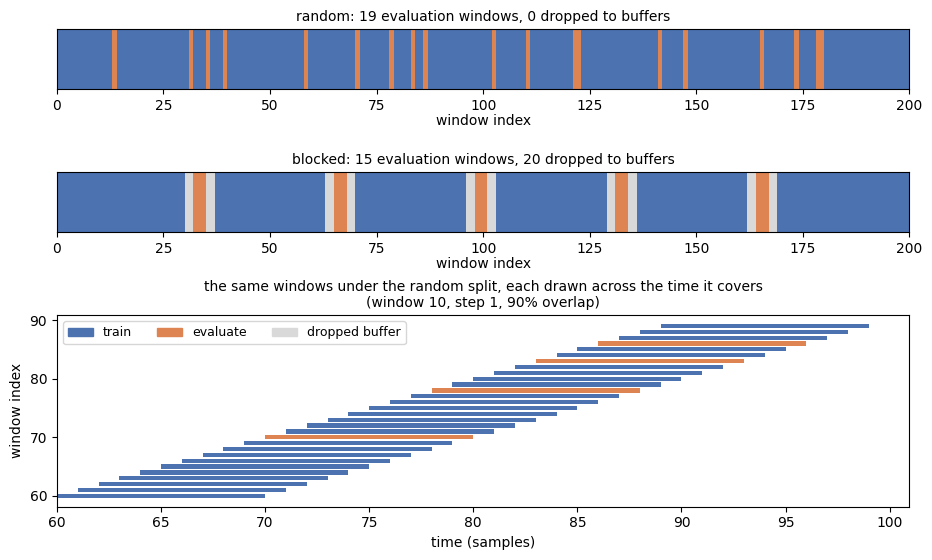

In [11]:
N_WIN, W_DEMO, STEP_DEMO = 200, 10, 1        # 90% overlap
TRAIN_FRAC, N_BLOCKS, GAP_FRAC = 0.9, 5, 0.5  # the library's defaults
TRAIN_C, TEST_C, GAP_C = '#4C72B0', '#DD8452', '0.85'

n_test = int(N_WIN * (1 - TRAIN_FRAC))
role_random = np.zeros(N_WIN, dtype=int)
role_random[rng.permutation(N_WIN)[:n_test]] = 1

block = n_test // N_BLOCKS
gap = int(round(GAP_FRAC * block))
role_blocked = np.zeros(N_WIN, dtype=int)
for start in np.linspace(0, N_WIN - block, N_BLOCKS + 2)[1:-1].astype(int):
    lo, hi = max(0, start - gap), min(N_WIN, start + block + gap)
    role_blocked[lo:hi] = np.where(role_blocked[lo:hi] == 0, 2, role_blocked[lo:hi])
    role_blocked[start:start + block] = 1

fig = plt.figure(figsize=(11, 6.2))
gs = fig.add_gridspec(3, 1, height_ratios=[0.5, 0.5, 1.6], hspace=0.8)
for slot, role, name in ((0, role_random, 'random'), (1, role_blocked, 'blocked')):
    ax = fig.add_subplot(gs[slot])
    for k in range(N_WIN):
        ax.axvspan(k, k + 1, color=(TRAIN_C, TEST_C, GAP_C)[role[k]], lw=0)
    ax.set_xlim(0, N_WIN)
    ax.set_yticks([])
    ax.set_xlabel('window index', labelpad=1)
    ax.set_title(f"{name}: {(role == 1).sum()} evaluation windows, "
                 f"{(role == 2).sum()} dropped to buffers", fontsize=10)

LO, HI = 60, 90
zoom = fig.add_subplot(gs[2])
for k in range(LO, HI):
    zoom.barh(k, W_DEMO, left=k * STEP_DEMO, height=0.72,
              color=(TRAIN_C, TEST_C, GAP_C)[role_random[k]])
zoom.set_xlabel('time (samples)')
zoom.set_ylabel('window index')
zoom.set_title(f'the same windows under the random split, each drawn across the time '
               f'it covers\n(window {W_DEMO}, step {STEP_DEMO}, '
               f'{100 * (1 - STEP_DEMO / W_DEMO):.0f}% overlap)', fontsize=10)
zoom.legend(handles=[Patch(color=TRAIN_C, label='train'),
                     Patch(color=TEST_C, label='evaluate'),
                     Patch(color=GAP_C, label='dropped buffer')],
            fontsize=9, loc='upper left', ncol=3)

plt.show()

The bottom panel of the figure shows the leak directly. Every evaluation window
there sits inside a stack of training windows covering almost the same samples.

Because the blocked scheme drops the buffer windows on both sides of each
evaluation run, a blocked split trains on fewer windows than a random one out of
the same recording.

## 7. Measuring the inflation

We sweep the overlap under both schemes against a known answer on the Gaussian process from notebook 03.

In [12]:
CFG = dict(dims={'x': 8, 'y': 8}, d=2, phi=0.9, coupling=0.4, noise=1.0, seed=SEED)
oracle = SharedLatentGaussian(**CFG)
sample = oracle.sample(T=T, seed=SEED)
X, Y = sample['x'], sample['y']
exact_W = float(oracle.block_mi(W))
print(f"exact block MI at window {W}: {exact_W:.4f} bits")

SPLIT_MODEL = nmi.Model(embedding_dim=8, hidden_dim=128, n_layers=2)
SPLIT_TRAIN = nmi.Training(n_epochs=N_EPOCHS, batch_size=256, patience=30,
                           learning_rate=1e-3)

# All three axes go in one grid. step_size and split_mode are the variables to
# group on and run_id is the repeat, so the frame comes back with a mean and a
# spread at every (overlap, split) pair.
t_all = time.time()
swept = nmi.run(X, Y, mode='sweep',
                sweep_grid={'step_size': OVERLAP_STEPS,
                            'split_mode': SPLIT_MODES,
                            'run_id': list(range(N_SEEDS))},
                processing=nmi.Processing(
                    x='continuous',
                    x_params={'window_size': W, 'step_size': OVERLAP_STEPS[0]},
                    y_params={'window_size': W, 'step_size': OVERLAP_STEPS[0]}),
                model=SPLIT_MODEL, training=SPLIT_TRAIN,
                estimator=nmi.Estimator('infonce'),
                n_workers=N_WORKERS, seed=SEED, show_progress=False)

leak = {}
for row in swept.dataframe.itertuples():
    leak[(row.split_mode, row.step_size)] = (row.mi_mean, row.mi_std)
for step in OVERLAP_STEPS:
    for mode in SPLIT_MODES:
        m, sdv = leak[(mode, step)]
        print(f"overlap {100 * (1 - step / W):>3.0f}%  {mode:<8}  "
              f"est={m:.4f} +/- {sdv:.4f}  ratio={m / exact_W:.3f}")
print(f"total {time.time() - t_all:.0f}s")

exact block MI at window 10: 4.5227 bits


ipykernel_92097/3855263213.py:16: UserWarning: Training completed all 200 epoch(s) without early stopping and the best (smoothed) test MI occurred at the final epoch. MI may still have been rising when training stopped. The reported estimate may then be an under-trained lower bound. Raise n_epochs or lower patience to let early stopping act.
  swept = nmi.run(X, Y, mode='sweep',


2026-09-30 18:16:11 - neural_mi - WARNING - 'Training completed all 200 epoch(s) without early stopping and the best (smoothed) test MI...' was raised 3 times in this cell and shown once.


overlap  90%  blocked   est=4.5648 +/- 0.1094  ratio=1.009
overlap  90%  random    est=7.6072 +/- 0.0400  ratio=1.682
overlap  80%  blocked   est=4.5137 +/- 0.3764  ratio=0.998
overlap  80%  random    est=6.1511 +/- 0.0660  ratio=1.360
overlap  50%  blocked   est=4.4337 +/- 0.0663  ratio=0.980
overlap  50%  random    est=4.7121 +/- 0.0384  ratio=1.042
overlap   0%  blocked   est=4.1291 +/- 0.1685  ratio=0.913
overlap   0%  random    est=4.4091 +/- 0.0478  ratio=0.975
total 71s


In [13]:
# Each scheme is read against the exact value. Reading one against the other
# would make the blocked estimate a reference point, and it has sample-count
# effects of its own.
print(f"exact = {exact_W:.4f} bits")
print(f"{'overlap':>8} {'blocked':>10} {'vs exact':>10} {'random':>10} {'vs exact':>10}")
for step in OVERLAP_STEPS:
    ov = 100 * (1 - step / W)
    bm, _ = leak[('blocked', step)]
    rm, _ = leak[('random', step)]
    print(f"{ov:>7.0f}% {bm:>10.4f} {100 * (bm / exact_W - 1):>+9.0f}% "
          f"{rm:>10.4f} {100 * (rm / exact_W - 1):>+9.0f}%")

exact = 4.5227 bits
 overlap    blocked   vs exact     random   vs exact
     90%     4.5648        +1%     7.6072       +68%
     80%     4.5137        -0%     6.1511       +36%
     50%     4.4337        -2%     4.7121        +4%
      0%     4.1291        -9%     4.4091        -3%


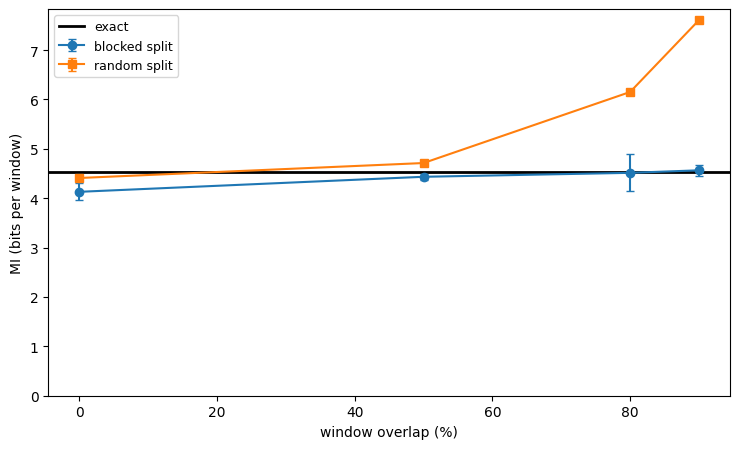

In [14]:
overlaps = [100 * (1 - st / W) for st in OVERLAP_STEPS]
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.axhline(exact_W, color='k', lw=2, label='exact')
for mode, marker in (('blocked', 'o'), ('random', 's')):
    ax.errorbar(overlaps, [leak[(mode, st)][0] for st in OVERLAP_STEPS],
                yerr=[leak[(mode, st)][1] for st in OVERLAP_STEPS],
                fmt=marker + '-', capsize=3, label=f'{mode} split')
ax.set_xlabel('window overlap (%)')
ax.set_ylabel('MI (bits per window)')
ax.legend(fontsize=9)
plt.ylim(bottom=0)
fig.tight_layout()
plt.show()

**The random split is inflated and it tracks the overlap.** It runs large at the
heaviest overlap, falls away as the overlap goes, and disappears once the
windows stop touching. Overlap can cause inflation. Random splitting on its own
does not.

**The blocked split is not inflated at any overlap.**

**The general rule:** Data in which two samples can be near-duplicates should
not be split at random. Overlapping windows and repeated stimuli are both cases
of it.

**Note:** Overlapping windows buy more samples without adding information. In
principle the extra samples should allow a better estimate of larger MI values
at larger window sizes. They are correlated and don't raise the ceiling the way
independent ones would. Overlapping windows do give the estimator more gradient
steps over different slices of the same data and make training longer and
potentially worse. The library does something similar by default with
`Training(shift_windows=True)`. At each epoch it shifts the start of the window
grid by a random integer offset within the window size so that the estimator
sees a slightly different set of windows every epoch instead of the same ones
over and over.

# Part III. Two hippocampal recordings

## 8. Tracking coverage

Here we load two sessions from rat hippocampus ([Grosmark and Buzsáki, 2016](https://doi.org/10.1126/science.aad1935)). An animal runs
a maze while silicon probes record sorted spikes and an overhead camera
tracks position. The linear session is a straight track and the circular one a
closed loop. Each ships the spikes, the tracked position, and a running
direction derived from that position.

All three kinds of data from Part I are here at once.

Start with how much of each session has usable tracking.

In [15]:
sessions, coverage = {}, {}
for name in ('linear', 'circular'):
    with open(f'{DATA}/hippocampus_{name}.pkl', 'rb') as f:
        sessions[name] = pickle.load(f)
    d = sessions[name]
    pos_t = np.asarray(d['pos_times_real'])
    dt = np.median(np.diff(pos_t))
    # A gap is a step much larger than the camera's own sampling interval.
    gaps = np.where(np.diff(pos_t) > 5 * dt)[0]
    starts = np.concatenate([[0], gaps + 1])
    ends = np.concatenate([gaps, [len(pos_t) - 1]])
    coverage[name] = dict(t=pos_t, starts=starts, ends=ends,
                          lengths=pos_t[ends] - pos_t[starts], gaps=gaps)

print(f"{'session':>10} {'neurons':>8} {'duration':>10} {'tracked':>10} "
      f"{'fraction':>9} {'fragments':>10} {'median':>8} {'longest':>8}")
for name, d in sessions.items():
    c = coverage[name]
    print(f"{name:>10} {d['n_neurons']:>8} {d['maze_duration']:>9.0f}s "
          f"{d['n_seconds_reindexed']:>9.0f}s "
          f"{100 * d['n_seconds_reindexed'] / d['maze_duration']:>8.0f}% "
          f"{len(c['lengths']):>10} {np.median(c['lengths']):>7.1f}s "
          f"{c['lengths'].max():>7.1f}s")

   session  neurons   duration    tracked  fraction  fragments   median  longest
    linear      120      2068s       265s       13%        138     1.9s     6.9s
  circular       92      2674s      1563s       58%        446     1.6s    31.4s


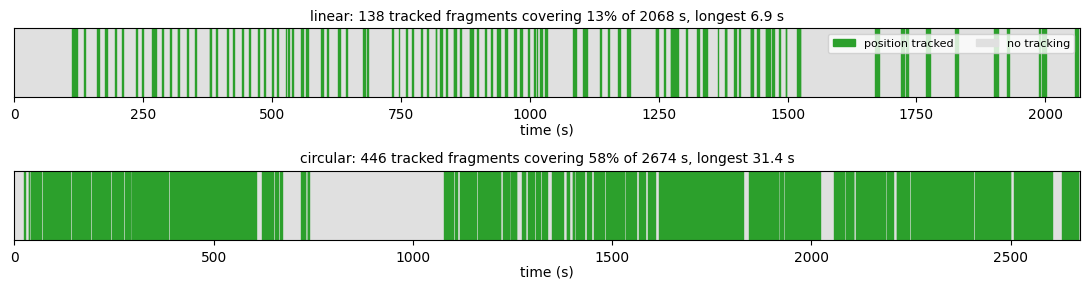

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(11, 3.0))
for ax, name in zip(axes, sessions):
    c, d = coverage[name], sessions[name]
    ax.axvspan(0, d['maze_duration'], color='0.88')
    for a, b in zip(c['t'][c['starts']], c['t'][c['ends']]):
        ax.axvspan(a, b, color='tab:green')
    ax.set_xlim(0, d['maze_duration'])
    ax.set_yticks([])
    ax.set_xlabel('time (s)', labelpad=1)
    ax.set_title(f"{name}: {len(c['lengths'])} tracked fragments covering "
                 f"{100 * d['n_seconds_reindexed'] / d['maze_duration']:.0f}% of "
                 f"{d['maze_duration']:.0f} s, longest {c['lengths'].max():.1f} s",
                 fontsize=10)
axes[0].legend(handles=[Patch(color='tab:green', label='position tracked'),
                        Patch(color='0.88', label='no tracking')],
               fontsize=8, ncol=2, loc='upper right')
fig.tight_layout()
plt.show()

The linear session has usable tracking for an eighth of its length, in a hundred and thirty-eight fragments with a median length under two seconds.
The longest unbroken run of tracking in the whole session is under seven
seconds.

You cannot fill a window longer than the fragment it falls in.

## 9. All three data types in one recording

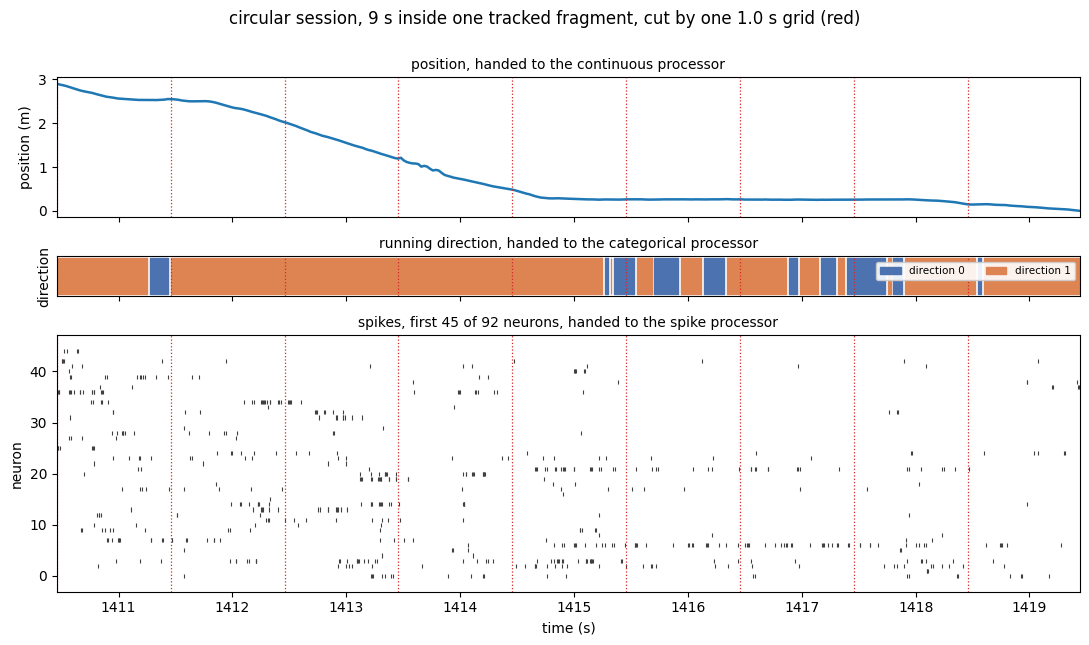

In [17]:
SHOW = 'circular'
d = sessions[SHOW]
c = coverage[SHOW]
pos = np.asarray(d['pos_1d'])
directions = np.asarray(d['directions'])
spikes = [np.asarray(s) for s in d['spikes_real']]
WIN_REAL = 1.0

# Show the longest fragment in which the animal traverses the maze.
usable = np.where(c['lengths'] >= 8)[0]
spans = np.array([pos[a:b + 1].ptp() for a, b in zip(c['starts'], c['ends'])])
pick = usable[np.argmax(spans[usable])]
t0 = c['t'][c['starts'][pick]]
t1 = min(t0 + 9.0, c['t'][c['ends'][pick]])
inside = (c['t'] >= t0) & (c['t'] <= t1)
N_SHOW = 45

fig, axes = plt.subplots(3, 1, figsize=(11, 6.4), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 0.34, 2.2]})
axes[0].plot(c['t'][inside], pos[inside], '-', lw=1.8, color='tab:blue')
axes[0].set_ylabel('position (m)')
axes[0].set_title('position, handed to the continuous processor', fontsize=10)

for value, colour in ((0, '#4C72B0'), (1, '#DD8452')):
    axes[1].fill_between(c['t'][inside], 0, 1,
                         where=(directions[inside] == value), color=colour,
                         step='post', label=f'direction {value}')
axes[1].set_yticks([])
axes[1].set_ylabel('direction')
axes[1].set_title('running direction, handed to the categorical processor',
                  fontsize=10)
axes[1].legend(fontsize=7.5, ncol=2, loc='upper right', framealpha=0.9)

axes[2].eventplot([s[(s >= t0) & (s <= t1)] for s in spikes[:N_SHOW]],
                  colors='0.25', linewidths=0.8, lineoffsets=np.arange(N_SHOW),
                  linelengths=0.8)
axes[2].set_ylabel('neuron')
axes[2].set_xlabel('time (s)')
axes[2].set_title(f'spikes, first {N_SHOW} of {d["n_neurons"]} neurons, handed to '
                  'the spike processor', fontsize=10)

for ax in axes:
    for edge in np.arange(t0, t1 + 1e-9, WIN_REAL):
        ax.axvline(edge, color='tab:red', lw=0.9, ls=':')
    ax.set_xlim(t0, t1)
fig.suptitle(f'{SHOW} session, {t1 - t0:.0f} s inside one tracked fragment, '
             f'cut by one {WIN_REAL} s grid (red)', y=1.0)
fig.tight_layout()
plt.show()

In [18]:
pos_t = np.asarray(d['pos_times_real'])
built = create_dataset(OrderedDict((
    ('spikes',    dict(data=spikes, processor_type='spike',
                       processor_params={'window_size': WIN_REAL, 'bin_size': 0.1})),
    ('position',  dict(data=pos, time=pos_t, processor_type='continuous',
                       processor_params={'window_size': WIN_REAL})),
    ('direction', dict(data=directions, time=pos_t, processor_type='categorical',
                       processor_params={'window_size': WIN_REAL})),
)))

print(f"at window_size = {WIN_REAL} s on the {SHOW} session, one shared grid "
      f"from {built.window_manager.window_times[0]:.1f} s:")
for name, note in (('spikes', 'one slot per 0.1 s bin'),
                   ('position', 'one slot per camera frame'),
                   ('direction', 'one slot per category')):
    shape = tuple(built.stream(name).data.shape)
    print(f"  {name:<10}-> {str(shape):<16} width {shape[-1]:>2}, {note}")
print(f"  kept {built.n_windows_retained} of {built.n_windows_built} windows "
      f"({built.window_retention:.0%}), the ones where all three have data")

2026-09-30 18:16:11 - neural_mi - WARNING - ContinuousWindowDataset: 300/1754 retained window(s) have over 30% of their samples bridged by interpolation across a gap more than 3x the typical inter-sample period. These windows passed min_coverage_fraction (enough raw timestamps are nearby) but much of their content may be fabricated by np.interp. Consider raising min_coverage_fraction or pre-collapsing large gaps in your data.


at window_size = 1.0 s on the circular session, one shared grid from 23.3 s:
  spikes    -> (1754, 92, 10)   width 10, one slot per 0.1 s bin
  position  -> (1754, 1, 40)    width 40, one slot per camera frame
  direction -> (1754, 1, 2)     width  2, one slot per category
  kept 1754 of 2647 windows (66%), the ones where all three have data


The result is three tensors with three widths and one shared first axis.
Binning the spike tensor instead of keeping its times is the encoding choice
from section 3.

All three counts match by construction because one grid is built across every
stream at once and keeps a window only where the spikes, the position and the
direction all have data. The retention line above shows that criterion dropping
about a third of the windows.

## 10. What the gaps cost in retention

In [19]:
WIN, BIN = 0.5, 0.1                  # seconds
STEP = 0.25                          # a quarter of the window, so 75% overlap
# window_size is below 1 and step_size is in (0, 1), so the library warns here
# and names the step it applied. Section 5 is the rule it is applying.

print(f"{'session':>10} {'min_coverage':>13} {'windows':>9}")
retention = {}
for name, sess in sessions.items():
    sp = [np.asarray(s) for s in sess['spikes_real']]
    p = np.asarray(sess['pos_1d'])
    pt = np.asarray(sess['pos_times_real'])
    retention[name] = {}
    for mcov in COVERAGE_GRID:
        built = create_dataset(
            sp, p, y_time=pt,
            processor_type_x='spike',
            processor_params_x={'window_size': WIN, 'step_size': STEP,
                                'bin_size': BIN},
            processor_type_y='continuous',
            processor_params_y={'window_size': WIN, 'step_size': STEP,
                                'min_coverage_fraction': mcov})
        retention[name][mcov] = len(built)
        print(f"{name:>10} {mcov:>13} {len(built):>9}")

ipykernel_92097/684887334.py:14: UserWarning: step_size=0.25 was read as a fraction of window_size=0.5. That gives a step of 0.125 time units and 75% overlap between consecutive windows. Every step_size below 1 is a fraction. If you meant 0.25 as an absolute duration, pass step_size=0.5 to get 0.25 as a fraction of the window. This is reported only when window_size is below 1. A fraction and a duration are then both plausible readings of the same number.
  built = create_dataset(


   session  min_coverage   windows


2026-09-30 18:16:11 - neural_mi - WARNING - Window coverage validation kept 2580 of 15619 windows (16.5%). Dropped per stream: Y (13039). The estimate describes the retained windows only. A per-window figure is per retained window. For spike data, {'drop_empty_windows': False} in the stream's processor parameters keeps silent windows and estimates the unrestricted quantity. Retention falls quickly as more variables are required to be simultaneously valid. This is reported once per run. The per-task values are in result.runs as 'window_retention'.


2026-09-30 18:16:11 - neural_mi - WARNING - ContinuousWindowDataset: 660/2580 retained window(s) have over 30% of their samples bridged by interpolation across a gap more than 3x the typical inter-sample period. These windows passed min_coverage_fraction (enough raw timestamps are nearby) but much of their content may be fabricated by np.interp. Consider raising min_coverage_fraction or pre-collapsing large gaps in your data.


    linear           0.0      2580


...

    linear           0.9      1720


  circular           0.0     13949


  circular           0.5     12701


2026-09-30 18:16:13 - neural_mi - WARNING - 'ContinuousWindowDataset: 660/2580 retained window(s) have over 30% of their samples bridge...' was raised 4 times in this cell and shown once.


  circular           0.9     10946


Tightening the requirement costs windows in both sessions. Because the
evaluation partition is a tenth of these windows, the ceiling $\log_2(\text{eval
size})$ differs between the two sessions.

Both sessions also ship a spliced timebase (`spikes_reindexed` and
`pos_times_reindexed`) with the untracked stretches removed. Windows then fill
completely and the retention problem goes away.

The splice charges for that in a different currency.

In [20]:
print(f"{'session':>10} {'joins':>7} {'gap removed':>13}")
for name, sess in sessions.items():
    real = np.asarray(sess['pos_times_real'])
    spliced = np.asarray(sess['pos_times_reindexed'])
    # A join is a sample pair where the real clock advanced further than the
    # spliced one. Those are the places where time was removed.
    joins = int(np.sum(np.diff(real) - np.diff(spliced) > 1e-6))
    print(f"{name:>10} {joins:>7} "
          f"{sess['maze_duration'] - sess['n_seconds_reindexed']:>12.0f}s")

   session   joins   gap removed
    linear     157         1803s
  circular     720         1111s


Every removed gap becomes a join where two moments that were seconds or minutes
apart are now adjacent. A window straddling a join contains a discontinuity the
animal never experienced.

For a question about instantaneous coding that is usually harmless. For a
question about what predicts what over time that is wrong.

## Where this goes next

This notebook completes the basic usage of the library. You now know how the
estimator works, how to process your data or let the library do it, and which
quantity to estimate. Notebook 05 finishes the series with more advanced options
like when to choose another estimator and how to pass a custom embedding
network. For standard estimations the defaults are sufficient.